#Imports

In [1]:
from PIL import Image
import os
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.math import confusion_matrix
from tensorflow.keras.callbacks import ModelCheckpoint
from PIL import Image
import io
from google.colab import files




In [2]:
class_names = {
    0: "brick",
    1: "diamond_ore",
    2: "emerald_block",
    3: "glowstone",
    4: "gold_ore",
    5: "iron_ore",
    6: "netherrack",
    7: "planks_oak",
    8: "sand"
}

## Subir modelo

In [5]:
def upload_model(new_path):
  new_model = tf.keras.models.load_model(new_path)
  return new_model


## Subir imagen

In [6]:
def evaluate_image(image, model):
  image = image.resize((128, 128))
  image = np.array(image)
  image = image / 255.0
  image = np.expand_dims(image, axis=0)
  prediction = model.predict(image)
  return prediction

In [7]:
def upload_image():
  uploaded = files.upload()
  file_name = list(uploaded.keys())[0]
  image = Image.open(io.BytesIO(uploaded[file_name]))
  image.show()
  return image


# Obtener Path de google drive

In [8]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
%cd "/content/drive/MyDrive/RecoCubes/"
!ls

/content/drive/MyDrive/RecoCubes
'diamond_ore_test (10).jpg'  'glostone_group (1).jfif'
'diamond_ore_test (11).jpg'  'glostone_group (2).jfif'
'diamond_ore_test (12).jpg'  'glostone_group (3).jfif'
'diamond_ore_test (1).jpg'   'glostone_group (4).jfif'
'diamond_ore_test (2).jpg'   'glostone_group (5).jfif'
'diamond_ore_test (3).jpg'   'glostone_group (6).jfif'
'diamond_ore_test (4).jpg'    glostone_group.jfif
'diamond_ore_test (5).jpg'    images
'diamond_ore_test (6).jpg'    modelos
'diamond_ore_test (7).jpg'   'Potone_Diamond_Ore (1).png'
'diamond_ore_test (8).jpg'   'Potone_Diamond_Ore (2).png'
'diamond_ore_test (9).jpg'   'Potone_Diamond_Ore (3).png'
 diamond_ore_test.jpg	      Potone_Diamond_Ore.png


# Preprocesamiento de datos

In [ ]:
def get_images_info_to_chart(test_generator):
  class_names = list(test_generator.class_indices.keys())
  print("Clases: ", class_names)
  all_images = []
  all_labels = []
  for index in range(len(test_generator)):
      images, labels = test_generator[index]
      all_images.append(images)
      all_labels.append(labels)
  return all_images, all_labels, class_names


In [10]:
def create_predictions(all_images, all_labels, model):
  test_images = np.concatenate(all_images)
  test_labels = np.concatenate(all_labels)

  predictions = model.predict(test_images)
  classes_x = np.argmax(predictions, axis=1)
  test_labels_indices = np.argmax(test_labels, axis=1)
  return classes_x, test_labels_indices


In [ ]:
def create_matrix(number_classes, all_labels, all_classes):
  matrix = np.zeros((number_classes, number_classes), dtype=int)
  for index in range (len(all_classes)):
    label = all_labels[index]
    classs = all_classes[index]
    matrix[label][classs] += 1
  return matrix

In [ ]:
def plot_matrix(matrix, model, number_classes, class_names):
  fig, ax = plt.subplots(figsize=(10, 8))
  im = ax.imshow(matrix, cmap=plt.cm.Blues)
  plt.colorbar(im)

  ax.set(
      xticks=np.arange(number_classes),
      yticks=np.arange(number_classes),
      xticklabels=class_names,
      yticklabels=class_names,
      xlabel='Predicción',
      ylabel='Real',
      title='Matriz de Confusión - ' + model
  )
  plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
  for i in range(number_classes):
    for j in range(number_classes):
      ax.text(j, i, str(matrix[i, j]), ha="center", va="center",
        color="white" if matrix[i, j] > matrix.max()/2 else "black")

  plt.tight_layout()
  plt.show()

In [11]:
def predict_image(model, class_names):
    image = upload_image()
    prediction = evaluate_image(image, model)

    class_index = np.argmax(prediction)
    class_name = class_names[class_index]
    confidence = prediction[0][class_index] * 100

    print(f"\nClase predicha: {class_name}")
    print(f"Confianza:      {confidence:.1f}%")
    print(f"\nProbabilidades por clase:")
    for index, probability in enumerate(prediction[0]):
        print(f"  {class_names[index]}: {probability*100:.1f}%")

## Validar tamaños

In [ ]:
def print_images_size_summary(sizes, clases_info):

  print("="*60)
  print("TAMAÑOS DE IMAGEN EN EL DATASET")
  print("="*60)

  contador = Counter(sizes)
  print(f"\nTotal imágenes analizadas: {len(sizes)}")
  print(f"Cantidad de tamaños diferentes: {len(contador)}")
  print(f"\nDistribución de tamaños:")
  for tamaño, cantidad in contador.most_common():
      print(f"  {tamaño[0]}x{tamaño[1]} píxeles: {cantidad} imágenes")

  print(f"\n{'='*60}")
  print("TAMAÑOS POR CLASE")
  print("="*60)
  for classes, sizes_clase in clases_info.items():
      count_class = Counter(sizes_clase)
      if len(count_class) == 1:
          size = list(count_class.keys())[0]
          print(f"{classes}: TODAS son {size[0]}x{size[1]}")
      else:
          print(f"{classes}: tiene {len(count_class)} tamaños diferentes")
          for s, c in count_class.items():
              print(f"      {s[0]}x{s[1]}: {c} imágenes")


In [ ]:
def get_size_images(base_dir):
  sizes = []
  clases_info = {}

  for clase in os.listdir(base_dir):
      clase_path = os.path.join(base_dir, clase)
      if os.path.isdir(clase_path):
          clase_sizes = []
          for img_name in os.listdir(clase_path):
              img_path = os.path.join(clase_path, img_name)
              try:
                  with Image.open(img_path) as img:
                      sizes.append(img.size)
                      clase_sizes.append(img.size)
              except:
                  pass
          clases_info[clase] = clase_sizes
  print_images_size_summary(sizes, clases_info)


In [ ]:
base_dir = 'images/train'
get_size_images(base_dir)

TAMAÑOS DE IMAGEN EN EL DATASET

Total imágenes analizadas: 630
Cantidad de tamaños diferentes: 1

Distribución de tamaños:
  128x128 píxeles: 630 imágenes

TAMAÑOS POR CLASE
diamond_ore: TODAS son 128x128
brick: TODAS son 128x128
glowstone: TODAS son 128x128
netherrack: TODAS son 128x128
iron_ore: TODAS son 128x128
gold_ore: TODAS son 128x128
emerald_block: TODAS son 128x128
planks_oak: TODAS son 128x128
sand: TODAS son 128x128


In [ ]:
base_dir = 'images/test'
get_size_images(base_dir)

TAMAÑOS DE IMAGEN EN EL DATASET

Total imágenes analizadas: 135
Cantidad de tamaños diferentes: 1

Distribución de tamaños:
  128x128 píxeles: 135 imágenes

TAMAÑOS POR CLASE
brick: TODAS son 128x128
emerald_block: TODAS son 128x128
diamond_ore: TODAS son 128x128
iron_ore: TODAS son 128x128
glowstone: TODAS son 128x128
gold_ore: TODAS son 128x128
netherrack: TODAS son 128x128
planks_oak: TODAS son 128x128
sand: TODAS son 128x128


In [ ]:
base_dir = 'images/validation'
get_size_images(base_dir)

TAMAÑOS DE IMAGEN EN EL DATASET

Total imágenes analizadas: 135
Cantidad de tamaños diferentes: 1

Distribución de tamaños:
  128x128 píxeles: 135 imágenes

TAMAÑOS POR CLASE
diamond_ore: TODAS son 128x128
emerald_block: TODAS son 128x128
brick: TODAS son 128x128
glowstone: TODAS son 128x128
iron_ore: TODAS son 128x128
gold_ore: TODAS son 128x128
sand: TODAS son 128x128
netherrack: TODAS son 128x128
planks_oak: TODAS son 128x128


## Data Augmentation

In [ ]:
base_dir = 'images'
train_dir = os.path.join(base_dir,'train')
test_dir = os.path.join(base_dir, 'test')
validation_dir = os.path.join(base_dir, 'validation')

Criterios:


1.   Rotación aleatoria -30 y +30
2.   Reflejo horizontal
3.   Traslación en X hasta +- 10 pixeles
4.   Traslación en Y hasta +- 10 pixeles
5.   Escalamiento entre 0.9 y 1.0


Image augmentation para el modelo 1

In [ ]:
path = "/content/drive/MyDrive/RecoCubes/images"
train_datagen1 = ImageDataGenerator(
		 rescale = 1./255,
		 )

train_generator1 = train_datagen1.flow_from_directory(
							train_dir,
							target_size = (128, 128),
							batch_size = 9,
							class_mode ='categorical',
							save_to_dir= path + '/augmented',
              save_prefix='aug',
              save_format='png'
							)

Found 630 images belonging to 9 classes.


image augmentation para el modelo 2

In [ ]:
path = "/content/drive/MyDrive/RecoCubes/images"
train_datagen2 = ImageDataGenerator(
		 rescale = 1./255,
		 rotation_range=30,
		 horizontal_flip=True,
		 width_shift_range=10/128,
		 height_shift_range=10/128,
		 zoom_range=0.1,
		 )

train_generator2 = train_datagen2.flow_from_directory(
							train_dir,
							target_size = (128, 128),
							batch_size = 9,
							class_mode ='categorical',
							save_to_dir= path + '/augmented',
              save_prefix='aug',
              save_format='png'
							)

Found 630 images belonging to 9 classes.


# Confirmación del Data augmentation

(9, 128, 128, 3)
[[0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]]


<Figure size 640x480 with 0 Axes>

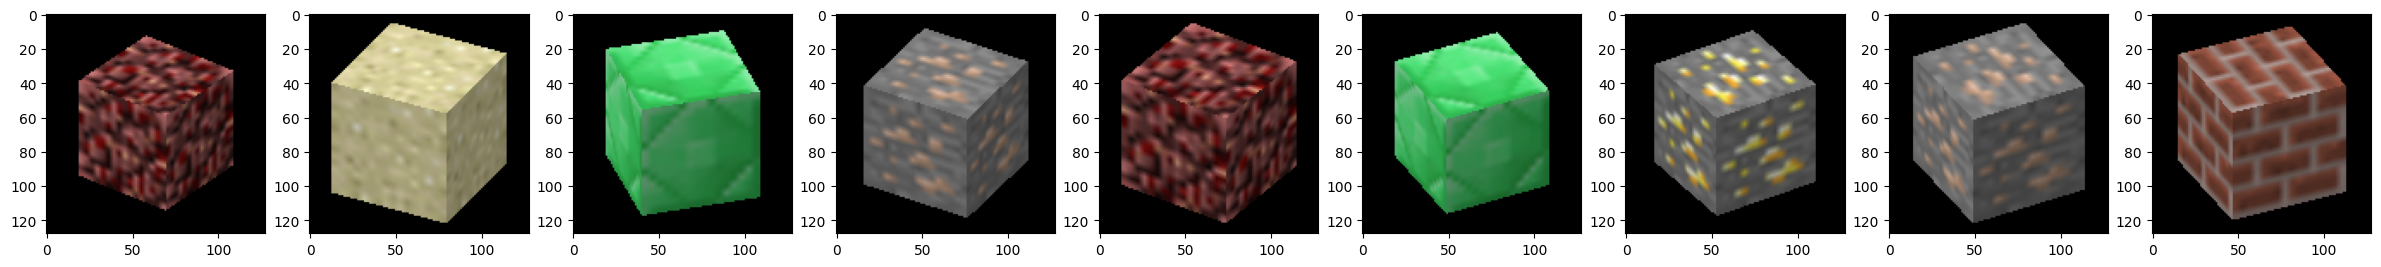

In [ ]:
images , labels = train_generator1[0]

print(images.shape)
print(labels)


plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 4))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

(9, 128, 128, 3)
[[0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]]


<Figure size 640x480 with 0 Axes>

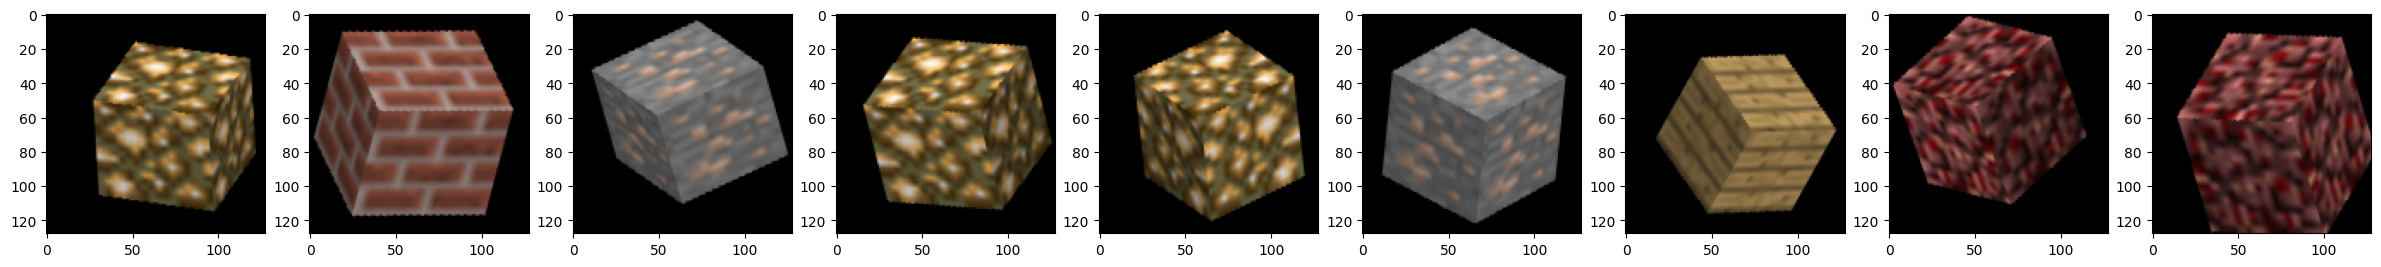

In [ ]:
images , labels = train_generator2[0]

print(images.shape)
print(labels)


plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 4))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

## Guardar Modelo

In [ ]:

checkpoint_path_best = base_dir + "/checkpoint_m1/checkpoint.weights.h5"

checkpoint_best = ModelCheckpoint(filepath= checkpoint_path_best,
                                  save_weights_only = False,
                                  save_freq = "epoch",
                                  monitor = "val_accuracy",
                                  save_best_only = True,
                                  verbose = 1)

In [ ]:

checkpoint_path_best2 = base_dir + "/checkpoint_m1/checkpoint2.weights.h5"

checkpoint_best2 = ModelCheckpoint(filepath= checkpoint_path_best2,
                                  save_weights_only = False,
                                  save_freq = "epoch",
                                  monitor = "val_accuracy",
                                  save_best_only = True,
                                  verbose = 1)

Modelo 1:

In [ ]:


model1 = models.Sequential()
model1.add(layers.Conv2D(10, (3, 3), activation="relu", input_shape = (128,128,3)))
model1.add(layers.Flatten())
model1.add(layers.Dense(256,activation='relu'))
model1.add(layers.Dense(9,activation='softmax'))

model1.summary()

model1.compile(loss='categorical_crossentropy',
						optimizer=optimizers.RMSprop(learning_rate=2e-5),
						metrics=[tf.keras.metrics.Precision(),
						         tf.keras.metrics.Accuracy(),
										 tf.keras.metrics.Recall(),
					 					 tf.keras.metrics.F1Score(),
                     "acc"
			            ])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 158760)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    40,642,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,645,409 (155.05 MB)

 Trainable params: 40,645,409 (155.05 MB)

 Non-trainable params: 0 (0.00 B)

Modelo 2:

In [ ]:
model2 = models.Sequential()
model2.add(layers.Conv2D(10, (3, 3), activation="relu", input_shape = (128,128,3)))
model2.add(layers.Flatten())
model2.add(layers.Dense(256,activation='relu'))
model2.add(layers.Dense(9,activation='softmax'))

model2.summary()

model2.compile(loss='categorical_crossentropy',
						optimizer=optimizers.RMSprop(learning_rate=2e-5),
						metrics=[tf.keras.metrics.Precision(),
						         tf.keras.metrics.Accuracy(),
										 tf.keras.metrics.Recall(),
					 					 tf.keras.metrics.F1Score(),
										 "acc"
			            ])


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 158760)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    40,642,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,645,409 (155.05 MB)

 Trainable params: 40,645,409 (155.05 MB)

 Non-trainable params: 0 (0.00 B)

##Train

In [ ]:
history1 = model1.fit(
						train_generator1,
						batch_size = 9,
						callbacks = [checkpoint_best],
						epochs = 12)



Epoch 1/12
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 806ms/step - acc: 0.2032 - accuracy: 0.0000e+00 - f1_score: 0.1817 - loss: 2.1878 - precision: 0.0789 - recall: 0.0014

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):



Epoch 1: finished saving model to images/checkpoint_m1/checkpoint.weights.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 70s 982ms/step - acc: 0.2968 - accuracy: 0.0000e+00 - f1_score: 0.2865 - loss: 1.9524 - precision: 0.5789 - recall: 0.0175
Epoch 2/12
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 919ms/step - acc: 0.5498 - accuracy: 0.0000e+00 - f1_score: 0.5112 - loss: 1.4157 - precision: 0.9231 - recall: 0.1000


Epoch 2: finished saving model to images/checkpoint_m1/checkpoint.weights.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - acc: 0.6111 - accuracy: 0.0000e+00 - f1_score: 0.6033 - loss: 1.3261 - precision: 0.9579 - recall: 0.1444  
Epoch 3/12
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 922ms/step - acc: 0.7602 - accuracy: 0.0000e+00 - f1_score: 0.7460 - loss: 1.0144 - precision: 0.9477 - recall: 0.3193


Epoch 3: finished saving model to images/checkpoint_m1/checkpoint.weights.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 68s 972ms/step - acc: 0.7810 - accuracy: 0.0000e+00 - f1_score: 0.7726 - loss: 0.9425 - precision: 0.9553 - recall: 0.3730
Epoch 4/12
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 922ms/step - acc: 0.8692 - accuracy: 0.0000e+00 - f1_score: 0.8597 - loss: 0.7189 - precision: 0.9892 - recall: 0.5618

...


Epoch 8: finished saving model to images/checkpoint_m1/checkpoint.weights.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 70s 986ms/step - acc: 0.9492 - accuracy: 0.0000e+00 - f1_score: 0.9487 - loss: 0.2571 - precision: 0.9813 - recall: 0.9143
Epoch 9/12
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 958ms/step - acc: 0.9691 - accuracy: 0.0000e+00 - f1_score: 0.9670 - loss: 0.2211 - precision: 0.9848 - recall: 0.9203


Epoch 9: finished saving model to images/checkpoint_m1/checkpoint.weights.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - acc: 0.9683 - accuracy: 0.0000e+00 - f1_score: 0.9684 - loss: 0.2073 - precision: 0.9800 - recall: 0.9317  
Epoch 10/12
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 961ms/step - acc: 0.9761 - accuracy: 0.0000e+00 - f1_score: 0.9614 - loss: 0.1644 - precision: 0.9920 - recall: 0.9617


Epoch 10: finished saving model to images/checkpoint_m1/checkpoint.weights.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - acc: 0.9778 - accuracy: 0.0000e+00 - f1_score: 0.9776 - loss: 0.1636 - precision: 0.9934 - recall: 0.9571  
Epoch 11/12
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 844ms/step - acc: 0.9888 - accuracy: 0.0000e+00 - f1_score: 0.9849 - loss: 0.1463 - precision: 0.9943 - recall: 0.9624


Epoch 11: finished saving model to images/checkpoint_m1/checkpoint.weights.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 82s 894ms/step - acc: 0.9825 - accuracy: 0.0000e+00 - f1_score: 0.9824 - loss: 0.1482 - precision: 0.9918 - recall: 0.9603
Epoch 12/12
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 953ms/step - acc: 0.9866 - accuracy: 0.0000e+00 - f1_score: 0.9796 - loss: 0.1118 - precision: 0.9889 - recall: 0.9783


Epoch 12: finished saving model to images/checkpoint_m1/checkpoint.weights.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - acc: 0.9810 - accuracy: 0.0000e+00 - f1_score: 0.9810 - loss: 0.1241 - precision: 0.9855 - recall: 0.9683  


In [ ]:
history2 = model2.fit(
						train_generator2,
						batch_size = 9,
						callbacks = [checkpoint_best2],
						epochs = 24)



Epoch 1/24
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 979ms/step - acc: 0.1747 - accuracy: 0.0000e+00 - f1_score: 0.1565 - loss: 2.3451 - precision_1: 0.1539 - recall_1: 0.0083


Epoch 1: finished saving model to images/checkpoint_m1/checkpoint2.weights.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - acc: 0.2413 - accuracy: 0.0000e+00 - f1_score: 0.2402 - loss: 2.0843 - precision_1: 0.2727 - recall_1: 0.0095  
Epoch 2/24
 3/70 ━━━━━━━━━━━━━━━━━━━━ 1:03 951ms/step - acc: 0.5926 - accuracy: 0.0000e+00 - f1_score: 0.3380 - loss: 1.6235 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00

KeyboardInterrupt: 

### Metricas
Para poner las metricas las obtuve de [https://www.geeksforgeeks.org/deep-learning/evaluation-metrics-in-tensorflow/]

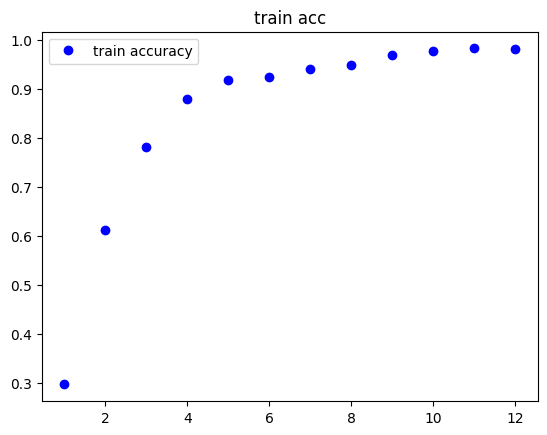

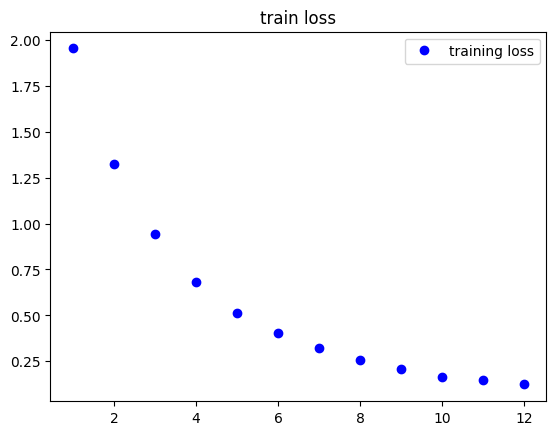

In [ ]:

acc = history1.history['acc']
f1_score = history1.history['f1_score']
loss = history1.history['loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs,acc,'bo',label='train accuracy')
plt.title('train acc')
plt.legend()

plt.figure()

plt.plot(epochs,loss, 'bo', label ='training loss')
plt.title('train loss')
plt.legend()

plt.show()

In [ ]:

acc = history2.history['acc']
f1_score = history2.history['f1_score']
loss = history2.history['loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs,acc,'bo',label='train accuracy')
plt.title('train acc')
plt.legend()

plt.figure()

plt.plot(epochs,loss, 'bo', label ='training loss')
plt.title('train loss')
plt.legend()

plt.show()

## Validation

In [ ]:
#EN test se usa las imagenes reales
validation_datagen1 = ImageDataGenerator(rescale=1./255)
validation_generator1 = validation_datagen1.flow_from_directory(
					validation_dir,
					target_size = (128, 128),
					batch_size = 20,
					class_mode= 'categorical')

validation_acc1 = model1.evaluate(validation_generator1, steps = 25)
print('\nvalidation acc :\n', validation_acc1)


Found 135 images belonging to 9 classes.
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - acc: 1.0000 - accuracy: 0.0000e+00 - f1_score: 1.0000 - loss: 0.1462 - precision: 1.0000 - recall: 0.9926 

validation acc :
 [0.14624521136283875, 1.0, 0.0, 0.9925925731658936, array([1., 1., 1., 1., 1., 1., 1., 1., 1.], dtype=float32), 1.0]


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [ ]:
print('loss:      ', validation_acc1[0])
print('precision: ', validation_acc1[1])
print('accuracy:  ', validation_acc1[2])
print('recall:    ', validation_acc1[3])
print('f1_score:  ', validation_acc1[4])
print('acc:       ', validation_acc1[5])

loss:       0.14624521136283875
precision:  1.0
accuracy:   0.0
recall:     0.9925925731658936
f1_score:   [1. 1. 1. 1. 1. 1. 1. 1. 1.]
acc:        1.0


In [ ]:
#EN test se usa las imagenes reales
validation_datagen2 = ImageDataGenerator(rescale=1./255)
validation_generator2 = validation_datagen2.flow_from_directory(
					validation_dir,
					target_size = (128, 128),
					batch_size = 20,
					class_mode= 'categorical')

validation_acc2 = model2.evaluate(validation_generator2, steps = 25)
print('\nvalidation acc :\n', validation_acc2)


In [ ]:
print('loss:      ', validation_acc2[0])
print('precision: ', validation_acc2[1])
print('accuracy:  ', validation_acc2[2])
print('recall:    ', validation_acc2[3])
print('f1_score:  ', validation_acc2[4])
print('acc:       ', validation_acc2[5])

##Test

In [ ]:
#EN test se usa las imagenes reales
test_datagen1 = ImageDataGenerator(rescale=1./255)
test_generator1 = test_datagen1.flow_from_directory(
					test_dir,
					target_size = (128, 128),
					batch_size = 20,
					class_mode= 'categorical')

test_acc1 = model1.evaluate(test_generator1, steps = 25)
print('\ntest acc :\n', test_acc1)


Found 135 images belonging to 9 classes.
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - acc: 0.9926 - accuracy: 0.0000e+00 - f1_score: 0.9926 - loss: 0.1380 - precision: 1.0000 - recall: 0.9778 

test acc :
 [0.13797353208065033, 1.0, 0.0, 0.9777777791023254, array([1.        , 1.        , 1.        , 1.        , 0.96774185,
       0.96551716, 1.        , 1.        , 1.        ], dtype=float32), 0.9925925731658936]


In [ ]:
print('loss:      ', test_acc1[0])
print('precision: ', test_acc1[1])
print('recall:    ', test_acc1[3])
print('f1_score:  ', test_acc1[4])
print('acc:       ', test_acc1[5])

loss:       0.13797353208065033
precision:  1.0
recall:     0.9777777791023254
f1_score:   [1.         1.         1.         1.         0.96774185 0.96551716
 1.         1.         1.        ]
acc:        0.9925925731658936


In [ ]:
#EN test se usa las imagenes reales
test_datagen2 = ImageDataGenerator(rescale=1./255)
test_generator2 = test_datagen2.flow_from_directory(
					test_dir,
					target_size = (128, 128),
					batch_size = 20,
					class_mode= 'categorical')

test_acc2 = model2.evaluate(test_generator2, steps = 25)
print('\ntest acc :\n', test_acc2)


Found 135 images belonging to 9 classes.
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - acc: 0.2741 - accuracy: 0.0000e+00 - f1_score: 0.1622 - loss: 1.8460 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 

test acc :
 [1.8460193872451782, 0.0, 0.0, 0.0, array([0.        , 0.        , 0.63636357, 0.        , 0.29702967,
       0.        , 0.52631575, 0.        , 0.        ], dtype=float32), 0.27407407760620117]


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [ ]:
print('loss:      ', test_acc2[0])
print('precision: ', test_acc2[1])
print('recall:    ', test_acc2[3])
print('f1_score:  ', test_acc2[4])
print('acc:       ', test_acc2[5])

loss:       1.8460193872451782
precision:  0.0
recall:     0.0
f1_score:   [0.         0.         0.63636357 0.         0.29702967 0.
 0.52631575 0.         0.        ]
acc:        0.27407407760620117


# Matriz de confusion

Clases:  ['brick', 'diamond_ore', 'emerald_block', 'glowstone', 'gold_ore', 'iron_ore', 'netherrack', 'planks_oak', 'sand']
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step


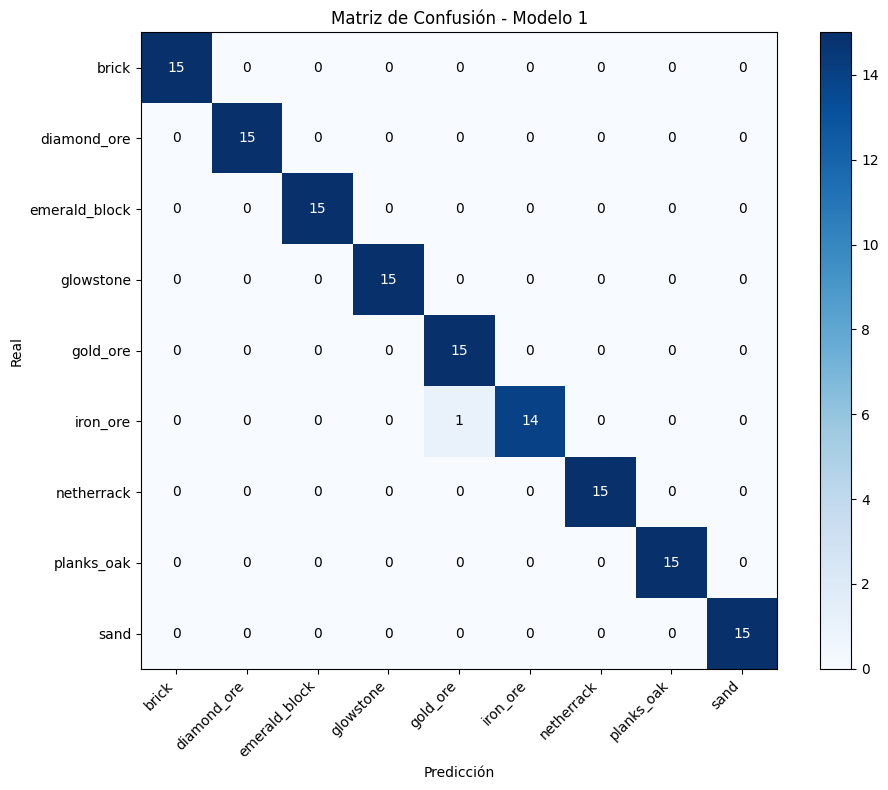

In [ ]:
all_images1, all_labels1, class_names1 = get_images_info_to_chart(test_generator1)
classes_x1, test_labels_indices1       = create_predictions(all_images1, all_labels1, model1)

matrix1 = create_matrix(9, test_labels_indices1, classes_x1)
plot_matrix(matrix1, 'Modelo 1', 9, class_names1)

In [ ]:
all_images2, all_labels2, class_names2 = get_images_info_to_chart(test_generator2)
classes_x2, test_labels_indices2       = create_predictions(all_images2, all_labels2, model2)

matrix2 = create_matrix(9, test_labels_indices2, classes_x2)
plot_matrix(matrix2, 'Modelo 2', 9, class_names2)

## Cargar Modelo


## Test - predecir imagen

In [ ]:
predict_image(model1, test_generator1)

Saving diamond_ore_test.jpg to diamond_ore_test (9).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step

Clase predicha: iron_ore
Confianza:      90.7%

Probabilidades por clase:
  brick: 0.0%
  diamond_ore: 9.1%
  emerald_block: 0.0%
  glowstone: 0.0%
  gold_ore: 0.1%
  iron_ore: 90.7%
  netherrack: 0.0%
  planks_oak: 0.0%
  sand: 0.1%


In [ ]:
predict_image(model2, test_generator2)

Saving diamond_ore_test.jpg to diamond_ore_test (10).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step

Clase predicha: iron_ore
Confianza:      34.0%

Probabilidades por clase:
  brick: 2.0%
  diamond_ore: 20.5%
  emerald_block: 17.5%
  glowstone: 2.1%
  gold_ore: 16.0%
  iron_ore: 34.0%
  netherrack: 4.4%
  planks_oak: 0.4%
  sand: 3.1%


## Probar cargar el modelo

In [ ]:
%pwd
%cd /content/


/content


In [ ]:
!ls

drive  sample_data


In [12]:
new_model = upload_model("/content/drive/MyDrive/RecoCubes/modelos/checkpointprueba.weights (1).h5")

In [17]:
predict_image(new_model, class_names=class_names)

Saving glostone_group.png to glostone_group.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step

Clase predicha: netherrack
Confianza:      59.1%

Probabilidades por clase:
  brick: 35.4%
  diamond_ore: 0.0%
  emerald_block: 0.0%
  glowstone: 2.6%
  gold_ore: 2.6%
  iron_ore: 0.2%
  netherrack: 59.1%
  planks_oak: 0.1%
  sand: 0.0%


In [14]:
new_model2 = upload_model("/content/drive/MyDrive/RecoCubes/modelos/checkpoint2.weights.h5")

In [18]:
predict_image(new_model2, class_names=class_names)

Saving glostone_group.png to glostone_group (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step

Clase predicha: glowstone
Confianza:      92.8%

Probabilidades por clase:
  brick: 2.9%
  diamond_ore: 0.0%
  emerald_block: 0.0%
  glowstone: 92.8%
  gold_ore: 4.3%
  iron_ore: 0.0%
  netherrack: 0.0%
  planks_oak: 0.0%
  sand: 0.0%
